<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/rf_tool_day_65.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import seaborn as sns


In [75]:
X,y = make_classification(n_features = 5, n_redundant= 0 , n_informative = 5, n_classes = 2, n_clusters_per_class= 1, n_samples= 200)

In [76]:
df = pd.DataFrame(X, columns = ['col1','col2','col3','col4','col5'])
df['target'] = y

In [77]:
print(df)

         col1      col2      col3      col4      col5  target
0    0.050422 -0.562317 -0.279327  2.777898 -3.091695       1
1    2.563242 -2.785763  3.875957  0.787359 -0.489911       1
2   -2.120715 -0.147724 -0.306609 -0.297086  0.185274       0
3    0.385837 -0.530283  2.162727 -0.309185 -0.477551       1
4    2.622721 -1.832023  1.958804  2.444132 -0.564917       1
..        ...       ...       ...       ...       ...     ...
195 -2.175721  0.493312  1.205439 -0.887991  1.172641       0
196  1.155257 -3.992443  0.836837 -0.641430  0.628308       0
197 -1.918420  0.632729  0.937161 -1.218275  1.006321       0
198  0.485904 -1.351749  0.273159 -1.942871  0.394538       0
199  2.147660 -2.895600  0.783931  1.238293 -1.838470       1

[200 rows x 6 columns]


In [78]:
#function for the row_sampling #with replacement
#Bagging
def sample_rows_fun(df,percent):
  return df.sample(int((percent*df.shape[0])), replace = True)

In [79]:
#function for the row_sampling #without replacement
#Pasting
def sample_rows_wo_fun(df,percent):
  return df.sample(int((percent*df.shape[0])), replace = False)

In [80]:
#function for the feature_sampling
#Random_subspace
def feature_sampling_fun(df,percent):
  cols = list(df.columns)
  cols.remove('target')
  return df[cols].sample(int((percent*len(cols))), axis = 1)


In [81]:
#Function for combined sampling
#Random_patches
def combined_sampling_fun(df,percent_col,percent_row):
  new_df = feature_sampling_fun(df,percent_col)
  return sample_rows_wo_fun(new_df,percent_row)


In [82]:
df = pd.DataFrame(X, columns = ['col1','col2','col3','col4','col5'])
df['target'] = y

df_sample = {}
for i in range(1,4):
  df_sample[i] = sample_rows_fun(df,0.5)
  print(df_sample[i])

         col1      col2      col3      col4      col5  target
14   2.534619 -2.891075  0.480249  4.007822 -3.211229       1
100 -0.368049 -0.511910 -2.101162  3.173001 -3.850952       1
103  1.580264 -1.625251  1.586139  0.131468 -0.377419       1
43  -0.544043 -0.822146  0.213795 -1.400417  0.307094       0
161  1.535428 -2.277040  0.958115 -1.975250  0.913338       0
..        ...       ...       ...       ...       ...     ...
132  1.348445 -3.058333  0.313539  2.721509 -4.171430       1
34   0.064510 -0.026973 -0.020563  1.300922 -1.215386       1
167 -4.440777  0.687023  1.524037  0.637018  1.365955       0
59  -0.136099  0.577992 -2.198376  0.910300 -0.877883       1
39  -1.451653 -1.445333  0.509828 -0.709842  0.608139       0

[100 rows x 6 columns]
         col1      col2      col3      col4      col5  target
45   1.794098 -1.125798 -1.892346  3.104792 -1.329026       1
185  3.142765 -3.285690  1.040349  3.467339 -2.330113       1
88  -2.527444  0.158158  1.540808 -0.263898  1

In [83]:
df1 = sample_rows_fun(df,0.2)
df2 = sample_rows_fun(df,0.2)
df3 = sample_rows_fun(df,0.2)

In [84]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [85]:
df1.iloc[:,0:5]

,col1,col2,col3,col4,col5
86,-3.250868,-0.384201,1.610828,0.196728,1.629473
2,-2.120715,-0.147724,-0.306609,-0.297086,0.185274
21,-0.238239,-2.398530,-0.318222,-1.297438,-0.366426
59,-0.136099,0.577992,-2.198376,0.910300,-0.877883
176,1.624660,-2.261470,2.867886,1.636937,-2.119688
127,0.958120,0.654683,-0.585673,1.013218,0.835771
118,-1.385291,-0.621827,2.551397,-0.926436,2.097193
109,-0.618589,0.429405,-0.619295,1.885135,-2.140597
67,0.019458,-0.664475,0.459461,-0.025742,-1.489784
181,1.179491,-1.029787,2.148151,-1.014432,0.447274


In [86]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [87]:
from sklearn.tree import plot_tree

[Text(0.4, 0.9, 'x[0] <= -0.897\ngini = 0.499\nsamples = 40\nvalue = [19, 21]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[3] <= -1.115\ngini = 0.375\nsamples = 28\nvalue = [7, 21]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[2] <= -0.52\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.3, 'x[0] <= 1.661\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'x[1] <= -2.663\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.7, 0.3, 'x[1] <= -3.243\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]')]

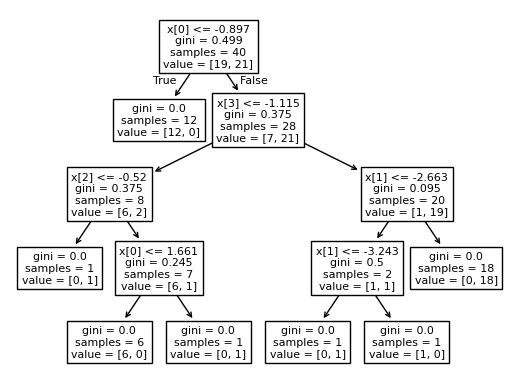

In [88]:
plot_tree(clf1)

[Text(0.3333333333333333, 0.875, 'x[4] <= -0.091\ngini = 0.495\nsamples = 40\nvalue = [22, 18]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.832\ngini = 0.26\nsamples = 26\nvalue = [22, 4]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.6666666666666666, 0.375, 'x[3] <= -1.942\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

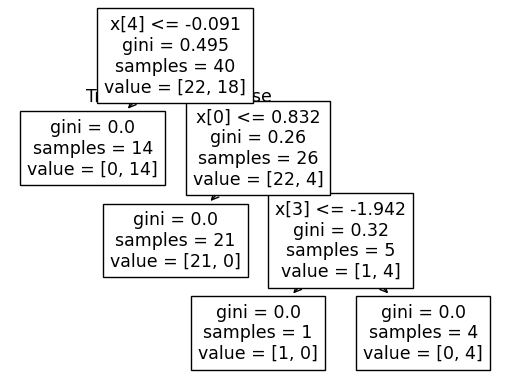

In [89]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[3] <= 0.283\ngini = 0.489\nsamples = 40\nvalue = [23, 17]'),
 Text(0.3333333333333333, 0.7, 'x[4] <= -0.389\ngini = 0.252\nsamples = 27\nvalue = [23, 4]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.5, 'x[1] <= 0.974\ngini = 0.08\nsamples = 24\nvalue = [23, 1]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.6666666666666666, 0.3, 'x[0] <= -1.131\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.5833333333333333, 0.8, '  False')]

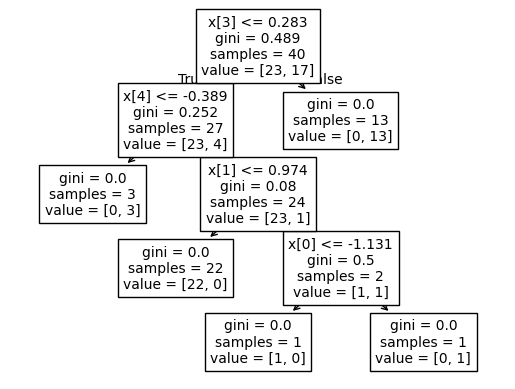

In [90]:
plot_tree(clf3)

In [131]:
(df.sample(axis = 0).values)

array([[-0.57627047,  0.723063  ,  1.85594309, -1.04798032,  0.21603884,
         1.        ]])

In [119]:
clf1.predict(np.array([0.48541483, -1.24517439,  1.92377084, -2.08584318,  1.9938638]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [120]:
clf2.predict(np.array([0.48541483, -1.24517439,  1.92377084, -2.08584318,  1.9938638]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [121]:
clf3.predict(np.array([0.48541483, -1.24517439,  1.92377084, -2.08584318,  1.9938638]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [122]:
from sklearn.ensemble import BaggingClassifier

In [126]:
bagc = BaggingClassifier(
    estimator = DecisionTreeClassifier(), # Corrected from base_estimator
    n_estimators = 500,
    max_samples = 0.2,
    bootstrap = True, # Corrected typo from bootstarp
    oob_score = True # Corrected from OOB_score (lowercase 'o')
    )

In [127]:
bagc.fit(df.iloc[:,0:5],df.iloc[:,-1])

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.2,
                  n_estimators=500, oob_score=True)

In [133]:
bagc.predict(np.array([-0.57627047,  0.723063  ,  1.85594309, -1.04798032,  0.21603884]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


array([0])

In [134]:
from sklearn.metrics import accuracy_score

In [136]:
accuracy_score(df.iloc[:,-1],bagc.predict(df.iloc[:,0:5]))

0.95

In [137]:
accuracy_score(df.iloc[:,-1],clf1.predict(df.iloc[:,0:5]))

0.87

In [139]:
#using the GridSearchCV
params = {
    'n_estimators' : [50,100,200,400,500],
    'max_samples' : [0.2,0.3,0.4,0.5,0.6,0.7],
    'bootstrap' : [True,False],
    'max_features' : [0.2,0.3,0.4,0.5]
}

In [140]:
from sklearn.model_selection import GridSearchCV

In [142]:
gdclf = GridSearchCV(bagc,params,cv = 5)